In [1]:
import pandas as pd 
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43
...,...,...,...,...,...
9563,15.12,48.92,1011.80,72.93,462.59
9564,33.41,77.95,1010.30,59.72,432.90
9565,15.99,43.34,1014.20,78.66,465.96
9566,17.65,59.87,1018.58,94.65,450.93


In [4]:
#AT = temparature 
# v = Vacume 
# AP = pressure 
# RH = humidity
# PE = produced energy

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = df.drop("PE",axis=1)
y = df["PE"]

In [7]:
# let spilit our dATA 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
df.shape

(9568, 5)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [10]:
X_train_scale

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [11]:
import torch 
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scale,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
X_test_tensor = torch.tensor(X_test_scale,dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [12]:
type(y_test)

pandas.core.series.Series

In [13]:
X_train_tensor

tensor([[ 0.7481,  0.7201, -0.3266, -0.4971],
        [ 0.8618,  1.2652, -0.9852,  0.8182],
        [ 0.9341,  1.5231,  0.3252,  0.8017],
        ...,
        [-0.2210, -0.8350,  0.3676, -0.8355],
        [ 0.9475,  1.1425, -0.4197, -0.4546],
        [-1.7736, -1.1905,  1.9252,  0.9184]])

In [14]:
from torch.utils.data import TensorDataset,DataLoader 
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset =TensorDataset(X_test_tensor,y_test_tensor)

In [15]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)

In [16]:
## Start Deeplearning & model architect
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        
        self.model = nn.Sequential(
        # 1st hiden layer 
            nn.Linear(X_train.shape[1],6) , # (in_feature,out feature)
            nn.ReLU(),
        # 2nd hiden layer
            nn.Linear(6,6) ,
            nn.ReLU(),
        # 3rd hiden layer 
            nn.Linear(6,1), # linear mean Z calculate / wheighted sum
    ) 

    def forward(self,x):
        return self.model(x)

In [17]:
import torch.optim as optim 

model=ANN()
# loss ,optimizer 
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

# Train the ANN

In [18]:
#Train the ANN
epochs = 100 
train_losses =[]
valids_losses = []
best_val_loss = float("inf") # best validation loss 
for epoch in range(epochs):
    model.train()
    running_loss = 0.0 #  total traing loss for 1 epoch 
    for xb,yb in train_loader : 
        #xb = feature of 1 batch 
        #yb = label of 1 batch /actual val
        optimizer.zero_grad() # to calculate fresh gradient each time
        outputs = model(xb) # predicted outputs . forward propregation
        loss = crietrion(outputs,yb) #compute Loss
        loss.backward() # back prop ...compute gradient
        optimizer.step() # it update param for all automaticaly
        running_loss+=loss.item()

    epoch_train_loss = running_loss / len(train_loader )
    train_losses.append(epoch_train_loss)


    #validation
    model.eval()
    running_val_loss = 0.0 # this val mean validation loss 
    with torch.no_grad():
         for xb,yb in test_loader :
             outputs = model(xb)
             loss = crietrion(outputs,yb)   
             running_val_loss+=loss.item()
    epoch_valid_loss = running_val_loss / len(test_loader )
    valids_losses.append(epoch_valid_loss) 
    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_valid_loss}")
        
    if epoch_valid_loss < best_val_loss:
        best_val_loss = epoch_valid_loss
        torch.save(model.state_dict(),"best_model.pt")

epoch 1/100 ==> train loss = 206380.879296875 & val loss = 204936.94088541667
epoch 2/100 ==> train loss = 199427.79928385417 & val loss = 189460.96328125
epoch 3/100 ==> train loss = 169447.60703125 & val loss = 144120.9671875
epoch 4/100 ==> train loss = 112215.18942057292 & val loss = 79383.93776041667
epoch 5/100 ==> train loss = 54443.1203125 & val loss = 35199.4380859375
epoch 6/100 ==> train loss = 26583.722912597656 & val loss = 20897.16336263021
epoch 7/100 ==> train loss = 18402.91678466797 & val loss = 16302.094368489583
epoch 8/100 ==> train loss = 14617.605541992187 & val loss = 12904.619466145834
epoch 9/100 ==> train loss = 11377.069281005859 & val loss = 9839.439078776042
epoch 10/100 ==> train loss = 8520.333050537109 & val loss = 7165.716634114583
epoch 11/100 ==> train loss = 6098.312192789714 & val loss = 4966.7177327473955
epoch 12/100 ==> train loss = 4159.784940592448 & val loss = 3306.852018229167
epoch 13/100 ==> train loss = 2753.3206939697266 & val loss = 215

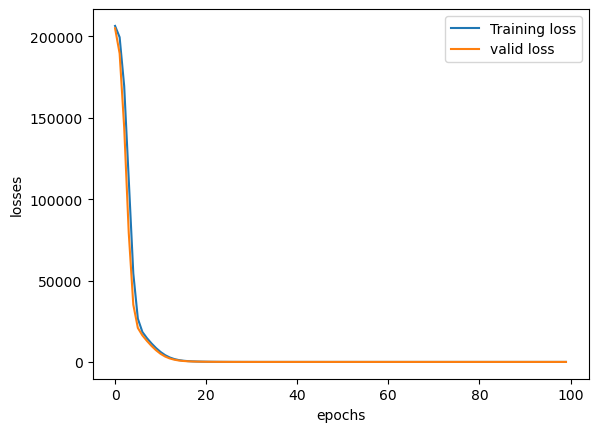

In [19]:
import matplotlib.pyplot as plt
loss_df = pd.DataFrame({
    "Training loss":train_losses,
    "valid loss":valids_losses
})
plt.plot(loss_df["Training loss"],label="Training loss")
plt.plot(loss_df["valid loss"],label="valid loss")
plt.xlabel("epochs")
plt.ylabel("losses")
plt.legend()

In [20]:
# loading best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [21]:
#Model Evaluate
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds,y_train_tensor)
    test_mse_loss = crietrion(test_preds,y_test_tensor)

print("Training MSE = ",train_mse_loss.item())
print("Test MSE = ",test_mse_loss.item())

Training MSE =  20.577930450439453
Test MSE =  18.89968490600586


In [22]:
from sklearn.metrics import r2_score
print("r2 score",r2_score(y_test,test_preds)*100,"%")

r2 score 93.39504819270263 %


In [23]:
#to compare actual value and predict value

In [24]:
predicted_df = pd.DataFrame(test_preds.numpy(),columns=["Predicted Value"])
actual_df = pd.DataFrame(y_test.values,columns=["Actual Value"])
pd.concat([predicted_df,actual_df],axis=1)

,Predicted Value,Actual Value
0,435.547821,433.27
1,437.112488,438.16
2,461.100372,458.42
3,475.965485,480.82
4,435.375641,441.41
...,...,...
1909,451.470947,456.70
1910,431.880280,438.04
1911,467.638763,467.80
1912,431.296875,437.14
